In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import warnings
warnings.simplefilter('ignore')

SEED = 30

In [2]:
df_test = pd.read_csv("/kaggle/input/playground-series-s5e6/test.csv")
df_train = pd.read_csv("/kaggle/input/playground-series-s5e6/train.csv")

In [3]:
le = LabelEncoder()
le.fit(df_train['Fertilizer Name'])

AGGREGATES = ['mean']
FEATURES = ['Temparature', 'Humidity', 'Moisture', 'Soil Type',
            'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous']

def make_log(df, features=FEATURES):
    """
    Makes log transformations for all features in features
    """
    df_temp = df.copy()
    features = list(df_temp[features].select_dtypes(include=['int64', 'float64']).columns)

    for feature in features:
        df_temp[f'{feature}_log'] = np.log1p(df_temp[feature])
    return df_temp

def make_interactions(df, features=FEATURES):
    """
    Makes interactions between all features listed in features
    """
    df_temp = df.copy()
    cat_cols = list(df_temp[features].select_dtypes(include=['category']).columns)
    num_features = list(df_temp[features].select_dtypes(include=['int64', 'float64']).columns)

    df_temp2 = pd.get_dummies(df_temp, columns=cat_cols)
    cat_features = list(df_temp2.select_dtypes(include=['bool']).columns)
    features = num_features + cat_features

    for i in range(len(features) - 1):
        for j in range(i, len(features) - 1):
            df_temp[f'{features[i]}_{features[j]}'] = df_temp2[features[i]] * df_temp2[features[j]]

    return df_temp

def make_polynomials(df, features=FEATURES):
    """
    Make polynomial of features listed in features
    Only does 2nd and 3rd power for now
    """
    df_temp = df.copy()
    num_features = list(df_temp[features].select_dtypes(include=['int64', 'float64']).columns)

    for feature in num_features:
        df_temp[f'{feature}2'] = df_temp[feature] ** 2
        df_temp[f'{feature}3'] = df_temp[feature] ** 3

    return df_temp

def make_aggregates(df, features=FEATURES):
    """
    Makes aggregates of features listed in features using the formula
    new_feature = X - aggregate_type(df.groupby(Y)[X])
    - where X is a numerical feature and Y is a categorical feature
    - chosen aggregates are set in AGGREGATES
    """
    df_temp = df.copy()
    num_cols = list(df[features].select_dtypes(include=['int64', 'float64']).columns)
    cat_cols = list(df[features].select_dtypes(include=['category']).columns)

    for cat_col in cat_cols:
        for agg_type in AGGREGATES:
            aggs = df_temp[num_cols] - df_temp.groupby(cat_col)[num_cols].transform(agg_type)
            aggs.columns  = [f"{cat_col}_{num_col}_{agg_type}" for num_col in aggs.columns]
            df_temp = pd.concat([df_temp, aggs], axis=1)
    return df_temp

def make_features(df, test=False):
    df_temp = df.copy()
    df_temp.drop(columns=['id'], inplace=True)
    cat_cols = df_temp.select_dtypes(include=['object']).columns
    df_temp[cat_cols] = df_temp[cat_cols].astype('category')
    df_temp = pd.get_dummies(df_temp, columns=['Soil Type', 'Crop Type'], drop_first=True)
    bool_cols = list(df_temp.select_dtypes(include=['bool']).columns)
    df_temp[bool_cols] = df_temp[bool_cols].astype('int64')

    if not test:
        df_temp['Fertilizer Name'] = le.transform(df_temp['Fertilizer Name'])

    # These Extra features are kinda useless
    # df_temp = make_log(df_temp)
    # df_temp = make_interactions(df_temp)
    # df_temp = make_polynomials(df_temp)
    # df_temp = make_aggregates(df_temp)
    
    return df_temp

In [4]:
df_train1 = make_features(df_train)
df_train1.head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Soil Type_Clayey,Soil Type_Loamy,Soil Type_Red,...,Crop Type_Cotton,Crop Type_Ground Nuts,Crop Type_Maize,Crop Type_Millets,Crop Type_Oil seeds,Crop Type_Paddy,Crop Type_Pulses,Crop Type_Sugarcane,Crop Type_Tobacco,Crop Type_Wheat
0,37,70,36,36,4,5,4,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,27,69,65,30,6,18,4,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,29,63,32,24,12,16,2,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,35,62,54,39,12,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,35,58,43,37,2,16,5,0,0,1,...,0,0,0,0,0,1,0,0,0,0


## Model Building

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
# set dataset to use
X = df_train1.drop(columns=['Fertilizer Name'])
y = df_train1[['Fertilizer Name']]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED)
X_train = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val.values, dtype=torch.float32).to(device).squeeze().long()

In [7]:
class mapk_loss_criterion(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_actual, k=3):
        topk_preds = torch.topk(y_pred, k, dim=1).indices
        y_actual = y_actual.view(-1, 1).expand_as(topk_preds)
    
        correct = (topk_preds == y_actual).float()

        precision_at_k = correct / (torch.arange(1, k+1, device=y_pred.device).float())
        ap = precision_at_k * correct
    
        return ap.sum(dim=1).mean().item()

In [8]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
        nn.Linear(INPUT_DIM, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Linear(32, 7)
    )

    def forward(self, X):
        return self.layers(X)

In [9]:
# hyperparameters
INPUT_DIM = df_train1.shape[1] - 1
LEARNING_RATE = 1e-3
BATCH=64
EPOCHS=500

mapk_loss = mapk_loss_criterion()

In [10]:
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size = BATCH)

In [11]:
model = NeuralNetwork().to(device)

In [12]:
criterion = nn.CrossEntropyLoss() # not using map@3 since not differentiable
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [13]:
all_train_ce_loss = []
all_train_mapk_loss = []
all_val_ce_loss = []
all_val_mapk_loss = []

torch.manual_seed(SEED)

for epoch in tqdm(range(EPOCHS)):
    model.train()
    epoch_ce_loss = 0 # cross entropy loss
    epoch_mapk_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).squeeze().long()
        optimizer.zero_grad()
    
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        epoch_ce_loss += loss.item()

        y_probs = torch.softmax(logits, dim=1)
        # topk_probs, topk_indices = torch.topk(y_probs, k=3, dim=1)
        batch_mapk_loss = mapk_loss(y_probs, y_batch)
        epoch_mapk_loss += batch_mapk_loss
        
        loss.backward()
        optimizer.step()
    
    # validation
    epoch_ce_loss /= len(loader)
    epoch_mapk_loss /= len(loader)
    all_train_ce_loss.append(epoch_ce_loss)
    all_train_mapk_loss.append(epoch_mapk_loss)
    model.eval()
    with torch.no_grad():
        logits = model(X_val)
        val_ce_loss = criterion(logits, y_val)
        all_val_ce_loss.append(val_ce_loss.item())

        y_probs = torch.softmax(logits, dim=1)
        # topk_probs, topk_indices = torch.topk(y_probs, k=3, dim=1)
        val_mapk_loss = mapk_loss(y_probs, y_val)
        all_val_mapk_loss.append(val_mapk_loss)
        

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"========== EPOCH :{epoch} ==========")
        print(f"Training Cross Entropy Loss: {epoch_ce_loss}")
        print(f"Training MAP@3 Loss: {epoch_mapk_loss}")
        print(f"Validation Cross Entropy Loss: {val_ce_loss}")
        print(f"Validation MAP@3 Loss: {val_mapk_loss}")

  0%|          | 1/500 [00:23<3:13:09, 23.23s/it]

========== EPOCH :0 ==========
Training Cross Entropy Loss: 1.944514888894087
Training MAP@3 Loss: 0.27826715230411403
Validation Cross Entropy Loss: 1.9418102502822876
Validation MAP@3 Loss: 0.28001633286476135


 20%|██        | 100/500 [37:26<2:29:39, 22.45s/it]

========== EPOCH :99 ==========
Training Cross Entropy Loss: 1.9346919217846674
Training MAP@3 Loss: 0.30180845153529373
Validation Cross Entropy Loss: 1.9385312795639038
Validation MAP@3 Loss: 0.29149705171585083


 40%|████      | 200/500 [1:14:47<1:51:34, 22.31s/it]

...

========== EPOCH :299 ==========
Training Cross Entropy Loss: 1.9323336343425823
Training MAP@3 Loss: 0.30741864670048047
Validation Cross Entropy Loss: 1.9390819072723389
Validation MAP@3 Loss: 0.2913326025009155


 80%|████████  | 400/500 [2:29:38<37:28, 22.49s/it]

========== EPOCH :399 ==========
Training Cross Entropy Loss: 1.9315731957562083
Training MAP@3 Loss: 0.3083264863437295
Validation Cross Entropy Loss: 1.9390801191329956
Validation MAP@3 Loss: 0.29159486293792725


100%|██████████| 500/500 [3:06:58<00:00, 22.44s/it]

========== EPOCH :499 ==========
Training Cross Entropy Loss: 1.9315574580230461
Training MAP@3 Loss: 0.30881183135297346
Validation Cross Entropy Loss: 1.9393503665924072
Validation MAP@3 Loss: 0.29171261191368103


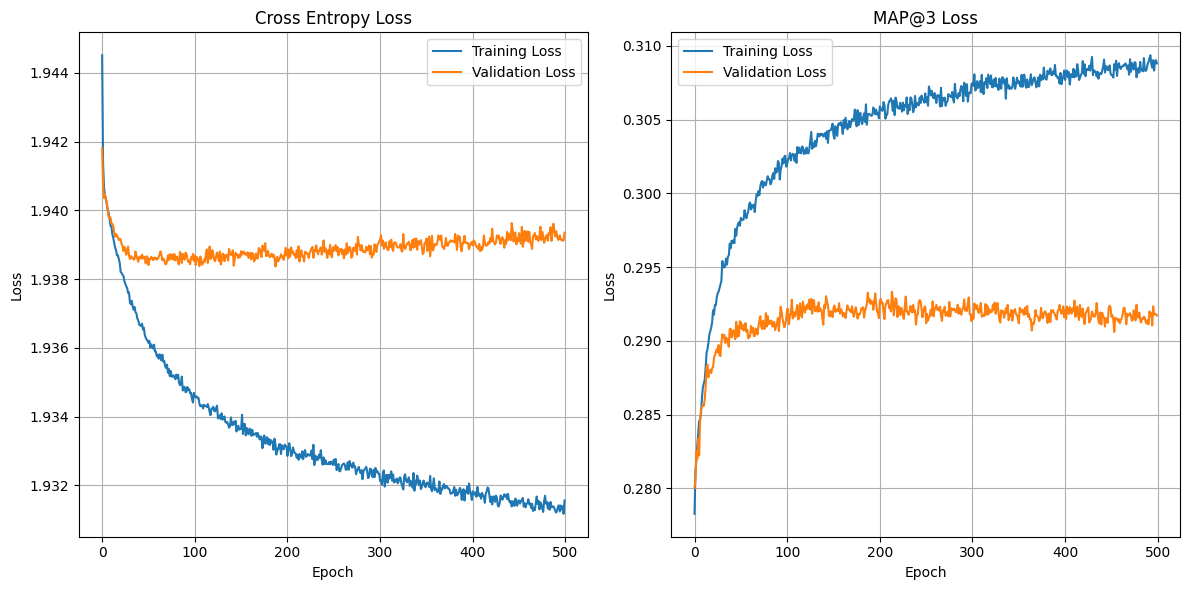

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()

axes[0].plot(all_train_ce_loss, label='Training Loss')
axes[0].plot(all_val_ce_loss, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Cross Entropy Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(all_train_mapk_loss, label='Training Loss')
axes[1].plot(all_val_mapk_loss, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('MAP@3 Loss')
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

In [15]:
df_test1 = make_features(df_test, test=True)
df_test1 = torch.tensor(df_test1.values, dtype=torch.float32)
df_test1 = df_test1.to(device)

In [16]:
test_logits = model(df_test1)
test_probs = torch.softmax(test_logits, dim=1)
test_pred_indices = torch.topk(test_probs, k=3, dim=1).indices
test_pred_indices = test_pred_indices.cpu().detach().numpy()
y_test_pred = [[le.classes_[j] for j in row] for row in test_pred_indices]
y_test_pred = [' '.join(row) for row in y_test_pred]

submission = pd.read_csv("/kaggle/input/playground-series-s5e6/sample_submission.csv")
submission['Fertilizer Name'] = y_test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,Fertilizer Name
0,750000,17-17-17 20-20 28-28
1,750001,17-17-17 10-26-26 14-35-14
2,750002,20-20 14-35-14 10-26-26
3,750003,14-35-14 20-20 28-28
4,750004,20-20 17-17-17 10-26-26
